Revisé un histórico de premios Grammy para ver si existe alguna relación entre ganar estos premios y cómo suenan esos artistas en Spotify. La idea con esto es descubrir si los ganadores tienen un perfil de audio diferente o si se nota algún patrón en su música. Para lograrlo, usé un proceso que unifica más de 114,000 canciones de Spotify con casi 5,000 registros de los Grammy desde 1958, y guardé todo ya consolidado en una base de datos.
Como quería que el análisis fuera lo más limpio posible, decidí medir todo a nivel de artista y puse un filtro estricto: solo incluí a quienes tienen un mínimo de tres canciones en la plataforma. Hice esto porque calcular el promedio de sonido de alguien con una sola canción no es confiable y podía alterar el resultado. De esta forma aseguro que los datos sean estables y realmente muestren lo que pasa con la música de los premiados.

In [25]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from sqlalchemy import text

sys.path.insert(0, str(Path.cwd().parent))        # permite importar config/ desde notebooks/
from config.settings import get_engine

engine = get_engine()                              # warehouse: localhost:5433 (Docker)
FIG_DIR = Path.cwd().parent / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def q(sql: str) -> pd.DataFrame:
    """Ejecuta SQL contra el warehouse. Es la ÚNICA fuente de datos del reporte."""
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)


# Paleta Pinterest 2026
WASABI, ORANGE, COOL_BLUE = "#E9F056", "#FF5C34", "#D7EFFF"
CASSIS, SAUGE = "#351E28", "#AEB8A0"

# Degradados: con Grammy = naranja a wasabi | sin Grammy = verde salvia a azul frío
GRAD_GRAMMY = LinearSegmentedColormap.from_list("grammy", [ORANGE, WASABI])
GRAD_OTHER = LinearSegmentedColormap.from_list("otros", [SAUGE, COOL_BLUE])
COL_GRAMMY, COL_OTHER = GRAD_GRAMMY(0.5), GRAD_OTHER(0.5)      # colores sueltos para las leyendas

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": CASSIS, "axes.facecolor": CASSIS, "savefig.facecolor": CASSIS,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": SAUGE, "xtick.color": COOL_BLUE, "ytick.color": COOL_BLUE,
    "text.color": COOL_BLUE, "axes.labelcolor": COOL_BLUE, "axes.titleweight": "bold",
    "grid.color": SAUGE, "grid.alpha": 0.18, "axes.axisbelow": True,
})


def pintar(ax, parche, cmap, vertical=True):
    """Rellena una barra o una caja con un degradado de la paleta."""
    caja = parche.get_bbox() if hasattr(parche, "get_bbox") else parche.get_path().get_extents()
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    paso = np.linspace(0, 1, 256)
    imagen = paso.reshape(-1, 1) if vertical else paso.reshape(1, -1)
    im = ax.imshow(imagen, extent=(caja.x0, caja.x1, caja.y0, caja.y1), origin="lower",
                   aspect="auto", cmap=cmap, vmin=0, vmax=1, zorder=parche.get_zorder())
    im.set_clip_path(parche)
    parche.set_facecolor("none")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)


MIN_TRACKS = 3

1. resumen de los datos q se cargan

In [26]:
meta = q("""
    SELECT COUNT(*)                                   AS artistas,
           SUM(CASE WHEN has_grammy THEN 1 ELSE 0 END) AS con_grammy,
           SUM(grammy_wins)                           AS premios,
           MAX(_pipeline_run_id)                      AS run_id,
           MAX(_extracted_at_utc)                     AS extraido_utc
    FROM artist_grammy_spotify
""").iloc[0]

print(f"Artistas en el dataset final : {int(meta['artistas']):,}")
print(f"Artistas con Grammy          : {int(meta['con_grammy']):,} ({meta['con_grammy'] / meta['artistas']:.1%})")
print(f"Premios asignados a artistas : {int(meta['premios']):,}")
print(f"Ejecución del pipeline       : {meta['run_id']}")
print(f"Datos extraídos (UTC)        : {meta['extraido_utc']}")

Artistas en el dataset final : 29,422
Artistas con Grammy          : 621 (2.1%)
Premios asignados a artistas : 1,861
Ejecución del pipeline       : manual__2026-10-07T07:09:54.384921+00:00
Datos extraídos (UTC)        : 2026-10-07T07:10:02+00:00


2. artistan con mas premios
> hay que tener en cuenta que algunos de los más premiados tienen muy pocas canciones en Spotify o su popularidad es casi 0: uno podria decir que se refleja el consumo actual, no la historia del premio del artista

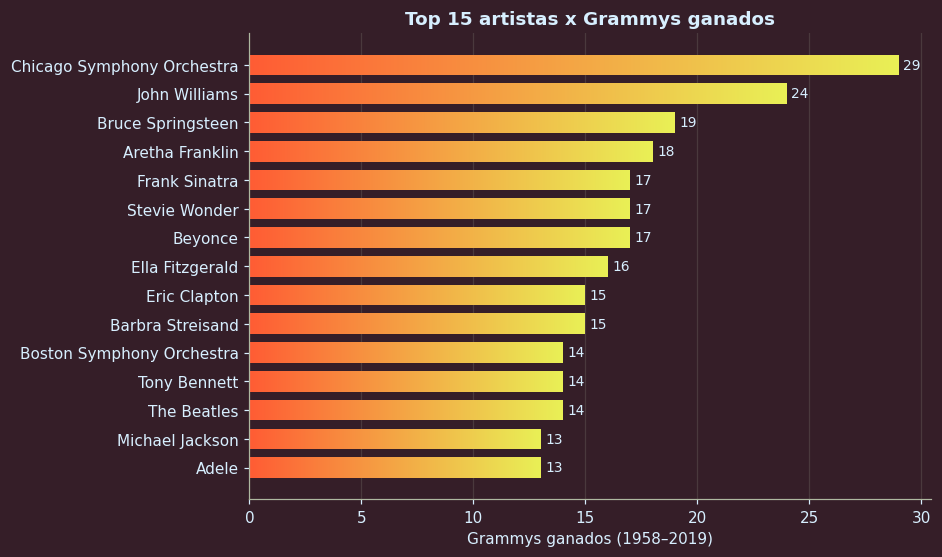

,artista,grammys,canciones_spotify,popularidad_media,primer_premio,ultimo_premio
0,chicago symphony orchestra,29,5,0.0000,1960,2008
1,john williams,24,6,26.1667,1975,2019
2,bruce springsteen,19,3,75.3333,1984,2011
3,aretha franklin,18,8,21.0000,1967,2005
4,stevie wonder,17,89,2.7528,1973,2005
5,beyonce,17,3,73.0000,2003,2019
6,frank sinatra,17,1,0.0000,1958,1995
7,ella fitzgerald,16,136,4.3456,1958,1994
8,eric clapton,15,12,60.4167,1988,2005
9,barbra streisand,15,3,66.0000,1963,2019


In [27]:
top = q("""
    SELECT artist_norm, grammy_wins, n_tracks, avg_popularity, first_win, last_win
    FROM artist_grammy_spotify
    ORDER BY grammy_wins DESC, n_tracks DESC
    LIMIT 15
""")

fig, ax = plt.subplots(figsize=(8, 5.5))
datos = top.sort_values("grammy_wins")
barras = ax.barh(range(len(datos)), datos["grammy_wins"], height=0.72)
for b in barras:
    pintar(ax, b, GRAD_GRAMMY, vertical=False)
ax.set_yticks(range(len(datos)))
ax.set_yticklabels(datos["artist_norm"].str.title())
ax.grid(axis="x")
for y, v in enumerate(datos["grammy_wins"]):
    ax.text(v + 0.2, y, str(int(v)), va="center", fontsize=9)
ax.set_xlabel("Grammys ganados (1958–2019)")
ax.set_title("Top 15 artistas x Grammys ganados")
fig.savefig(FIG_DIR / "01_top_artistas.png", bbox_inches="tight")
plt.show()

top.rename(columns={"artist_norm": "artista", "grammy_wins": "grammys", "n_tracks": "canciones_spotify",
                    "avg_popularity": "popularidad_media", "first_win": "primer_premio", "last_win": "ultimo_premio"}
           ).head(10)

3. Comparativa de audio entre artistas con y sin Grammy 

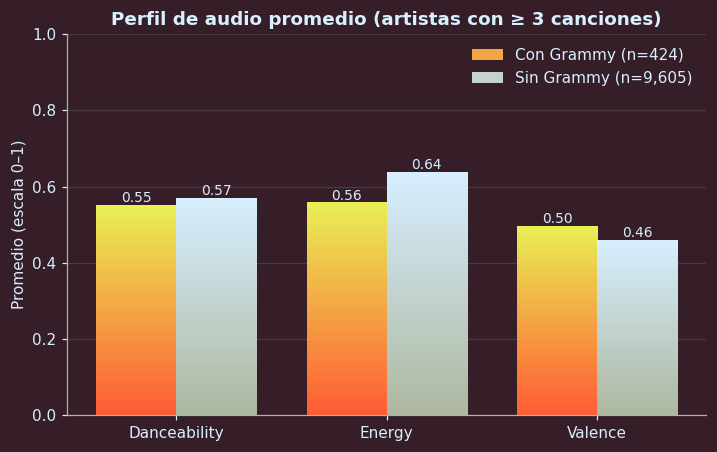

,artistas,danceability,energy,valence,popularidad
has_grammy,,,,,
False,9605,0.57,0.637,0.460,33.989
True,424,0.55,0.558,0.496,34.389


In [28]:
prof = q(f"""
    SELECT has_grammy,
           COUNT(*)              AS artistas,
           AVG(avg_danceability) AS danceability,
           AVG(avg_energy)       AS energy,
           AVG(avg_valence)      AS valence,
           AVG(avg_popularity)   AS popularidad
    FROM artist_grammy_spotify
    WHERE n_tracks >= {MIN_TRACKS}
    GROUP BY has_grammy
""")
prof["has_grammy"] = prof["has_grammy"].astype(bool)
prof = prof.set_index("has_grammy")

features = ["danceability", "energy", "valence"]
x = range(len(features))
w = 0.38

fig, ax = plt.subplots(figsize=(7.5, 4.5))
b1 = ax.bar([i - w / 2 for i in x], prof.loc[True, features], w,
            label=f"Con Grammy (n={int(prof.loc[True, 'artistas']):,})")
b2 = ax.bar([i + w / 2 for i in x], prof.loc[False, features], w,
            label=f"Sin Grammy (n={int(prof.loc[False, 'artistas']):,})")
for b in b1:
    pintar(ax, b, GRAD_GRAMMY)
for b in b2:
    pintar(ax, b, GRAD_OTHER)
ax.bar_label(b1, fmt="%.2f", fontsize=9)
ax.bar_label(b2, fmt="%.2f", fontsize=9)
ax.set_xticks(list(x))
ax.set_xticklabels([f.capitalize() for f in features])
ax.set_ylim(0, 1)
ax.set_ylabel("Promedio (escala 0–1)")
ax.set_title(f"Perfil de audio promedio (artistas con ≥ {MIN_TRACKS} canciones)")
ax.grid(axis="y")
ax.legend(handles=[Patch(facecolor=COL_GRAMMY, label=b1.get_label()),
                   Patch(facecolor=COL_OTHER, label=b2.get_label())], frameon=False)
fig.savefig(FIG_DIR / "02_perfil_audio.png", bbox_inches="tight")
plt.show()

prof.round(3)

4. seran más populares los artistas con Grammy? 

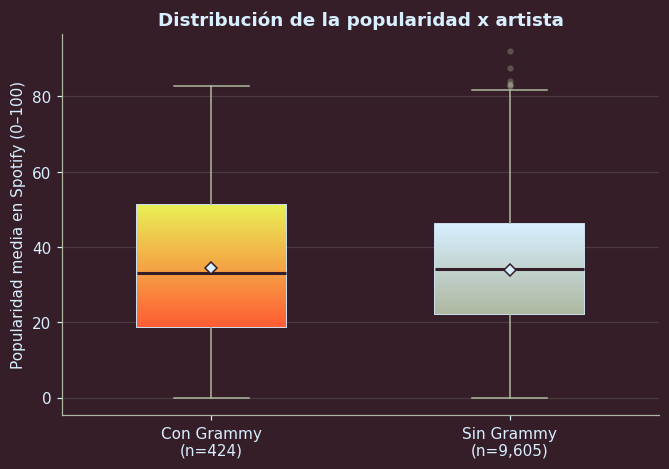

,con_grammy,sin_grammy
count,424.00,9605.00
mean,34.39,33.99
std,21.26,16.41
min,0.00,0.00
25%,18.67,22.20
50%,33.20,34.25
75%,51.06,46.00
max,82.75,92.00


In [29]:
pop = q(f"""
    SELECT has_grammy, avg_popularity
    FROM artist_grammy_spotify
    WHERE n_tracks >= {MIN_TRACKS}
""")
pop["has_grammy"] = pop["has_grammy"].astype(bool)
con = pop.loc[pop["has_grammy"], "avg_popularity"]
sin = pop.loc[~pop["has_grammy"], "avg_popularity"]

fig, ax = plt.subplots(figsize=(7, 4.5))
bp = ax.boxplot([con, sin], tick_labels=[f"Con Grammy\n(n={len(con):,})", f"Sin Grammy\n(n={len(sin):,})"],
                showmeans=True, patch_artist=True, widths=0.5,
                boxprops=dict(edgecolor=COOL_BLUE, linewidth=1.2),
                medianprops=dict(color=CASSIS, linewidth=2),
                meanprops=dict(marker="D", markerfacecolor=COOL_BLUE, markeredgecolor=CASSIS, markersize=6),
                whiskerprops=dict(color=SAUGE), capprops=dict(color=SAUGE),
                flierprops=dict(marker="o", markerfacecolor=SAUGE, markeredgecolor="none", alpha=0.35, markersize=4))
for patch, grad in zip(bp["boxes"], [GRAD_GRAMMY, GRAD_OTHER]):
    pintar(ax, patch, grad)
ax.grid(axis="y")
ax.set_ylabel("Popularidad media en Spotify (0–100)")
ax.set_title("Distribución de la popularidad x artista")
fig.savefig(FIG_DIR / "03_popularidad.png", bbox_inches="tight")
plt.show()

pd.DataFrame({"con_grammy": con.describe(), "sin_grammy": sin.describe()}).round(2)

5. Primer Grammy de cada artista x década

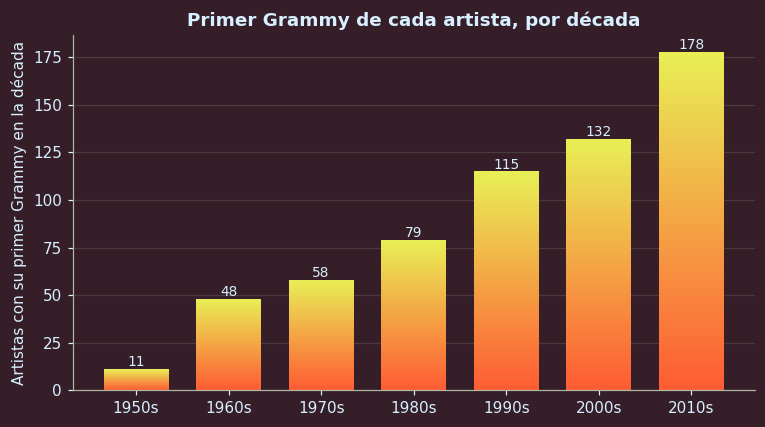

In [30]:
dec = q("""
    SELECT (first_win / 10) * 10 AS decada, COUNT(*) AS artistas
    FROM artist_grammy_spotify
    WHERE has_grammy
    GROUP BY 1
    ORDER BY 1
""")

fig, ax = plt.subplots(figsize=(8, 4.2))
pos = list(range(len(dec)))
barras = ax.bar(pos, dec["artistas"], width=0.7)
for b in barras:
    pintar(ax, b, GRAD_GRAMMY)
ax.set_xticks(pos)
ax.set_xticklabels(dec["decada"].astype(int).astype(str) + "s")
ax.bar_label(barras, fontsize=9)
ax.grid(axis="y")
ax.set_ylabel("Artistas con su primer Grammy en la década")
ax.set_title("Primer Grammy de cada artista, por década")
fig.savefig(FIG_DIR / "04_decadas.png", bbox_inches="tight")
plt.show()

6. Premios VS popularidad

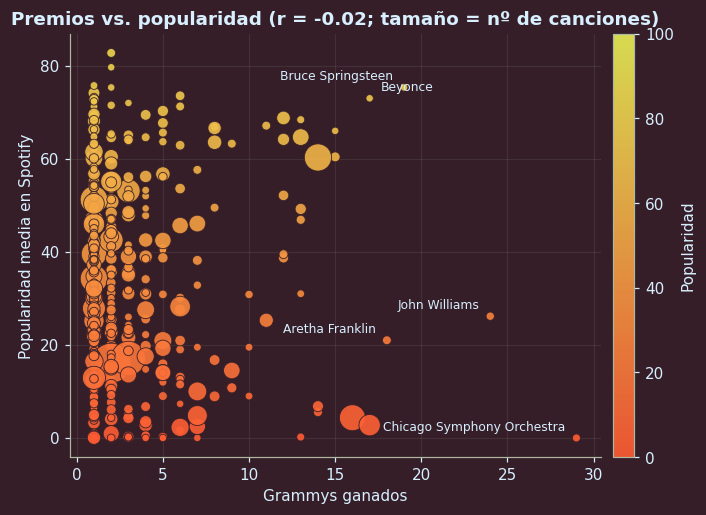

In [31]:
sc = q(f"""
    SELECT artist_norm, grammy_wins, avg_popularity, n_tracks
    FROM artist_grammy_spotify
    WHERE has_grammy AND n_tracks >= {MIN_TRACKS}
""")
corr = sc["grammy_wins"].corr(sc["avg_popularity"])

fig, ax = plt.subplots(figsize=(7.5, 5))
puntos = ax.scatter(sc["grammy_wins"], sc["avg_popularity"], s=18 + sc["n_tracks"] * 2,
                    c=sc["avg_popularity"], cmap=GRAD_GRAMMY, vmin=0, vmax=100,
                    alpha=0.9, edgecolor=CASSIS, linewidth=0.6)
barra = fig.colorbar(puntos, ax=ax, pad=0.02)
barra.set_label("Popularidad")
barra.outline.set_edgecolor(SAUGE)
ax.grid(alpha=0.12)
tope = sc["grammy_wins"].max()
for _, r in sc.nlargest(5, "grammy_wins").iterrows():
    a_la_derecha = r["grammy_wins"] > tope * 0.6          # si el punto está cerca del borde, el nombre va hacia adentro
    ax.annotate(r["artist_norm"].title(), (r["grammy_wins"], r["avg_popularity"]),
                textcoords="offset points", xytext=(-7 if a_la_derecha else 7, 5),
                ha="right" if a_la_derecha else "left", fontsize=8)
ax.set_xlabel("Grammys ganados")
ax.set_ylabel("Popularidad media en Spotify")
ax.set_title(f"Premios vs. popularidad (r = {corr:.2f}; tamaño = nº de canciones)")
fig.savefig(FIG_DIR / "05_premios_vs_popularidad.png", bbox_inches="tight")
plt.show()

7. que pude concluir
Lo primero que me llamó la atención es lo pocos que son. De más de 29,000 artistas que quedaron en la base de datos, solo 621 han ganado un Grammy, un 2.1%. Ganar uno de estos premios no es algo comun entre los artistas de Spotify.

Lo segundo es que ganar un Grammy no los hace más populares en este momento. Compare solo a los artistas con mínimo tres canciones, 424 con premio contra 9,605 sin premio, y los que tienen Grammy quedaron en 34.4 de popularidad y los otros en 34.0, eso practicamente es lo mismo. Tampoco se nota que los que más premios tienen sean los más escuchados. La Chicago Symphony Orchestra tiene 29 Grammys y su popularidad esta en cero, mientras que Bruce Springsteen y Beyonce si pasan de 70. Por eso pienso que el premio habla de una época y la popularidad habla de lo que la gente escucha ahora, y casi nunca van de la mano.

Donde si vi una diferencia, mas bien pequeña, fue en como suenan. Los artistas con Grammy tienen menos energia, 0.56 contra 0.64, y son un poco más alegres, 0.50 contra 0.46. En lo bailable casi no cambian. Lo que pienso es que esto puede venir del tipo de música que más premia el Grammy, como lo clásico, el jazz y la música de cine, y se ve en los más premiados, que son una orquesta y un compositor de cine. Esa música suele sonar más tranquila. Es solo una idea mía, los datos muestran la diferencia pero no el motivo.

Al final, mi respuesta a la pregunta inicial es que no hay un patrón fuerte entre ganar un Grammy y cómo le va a un artista en Spotify. Lo único que se nota es un sonido un poco más suave. Ganar un Grammy dice que un artista fue importante en su momento, pero no asegura que hoy lo escuchen mas.